## 1.1 DeepLDA CV on pairwise distances (heavy atoms) 

### (a) Train CV

To load the PLUMED output of the two unbiased MD runs we can use the [load_dataframe](https://mlcvs.readthedocs.io/en/latest/autosummary/mlcvs.utils.io.load_dataframe.html) function.
From this data, we build our training dataset. Since this is a supervised learning task, the dataset will be of the form (`X,y`), in which `X` are the input samples and `y` the corresponding labels (the states to which they belong to).

In [1]:
import os
import subprocess
from pathlib import Path
import torch
import lightning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from mlcolvar.utils.trainer import MetricsCallback

In [2]:
# Configurations
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
DATA_DIR    = BASE_DIR / "data"
GMX_CMD     = "gmx_mpi"  # I compiled gromacs with mpi support
#NUM_STEPS   = 10_000     # for testing  
NUM_STEPS   = 500_000    # productions
STRIDE      = 100

num_steps   = NUM_STEPS

os.chdir(BASE_DIR)

In [3]:
# Check working directory
os.getcwd()

'/home/dani/wslcoding/MCFM/ML-CV'

In [4]:
torch.set_float32_matmul_precision('high')

# Detect available accelerator
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
#accelerator = 'cpu'
print(f"Training on: {accelerator.upper()}")

Training on: GPU


### Load data


We use the alanine dipeptide simulation data from sample generation notebook

In [33]:
from mlcolvar.utils.io import create_dataset_from_files
from mlcolvar.data import DictModule

filenames = [ f"{DATA_DIR}/0_unbiased-sA/COLVAR", 
              f"{DATA_DIR}/0_unbiased-sB/COLVAR" ]

n_states = len(filenames)

# load dataset
dataset, colvar = create_dataset_from_files(filenames,
                                        filter_args={'regex':'d_' }, # select distances between heavy atoms
                                        create_labels=True,
                                        return_dataframe=True, 
                                        )

# default parameters batch size = len(dataset), shuffle = True
datamodule = DictModule(dataset,lengths=[0.8,0.2])

Class 0 dataframe shape:  (5001, 53)
Class 1 dataframe shape:  (5001, 53)

 - Loaded dataframe (10002, 53): ['time', 'phi', 'psi', 'theta', 'xi', 'ene', 'd_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15', 'd_11_16', 'd_11_17', 'd_11_19', 'd_15_16', 'd_15_17', 'd_15_19', 'd_16_17', 'd_16_19', 'd_17_19', 'walker', 'labels']
 - Descriptors (10002, 45): ['d_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15

In [6]:
datamodule

DictModule(dataset -> DictDataset( "data": [10002, 45], "labels": [10002] ),
		     train_loader -> DictLoader(length=0.8, batch_size=0, shuffle=True),
		     valid_loader -> DictLoader(length=0.2, batch_size=0, shuffle=True))

We can inspect the distances through their histograms, from which we notice that no one is able to discriminate between the states.

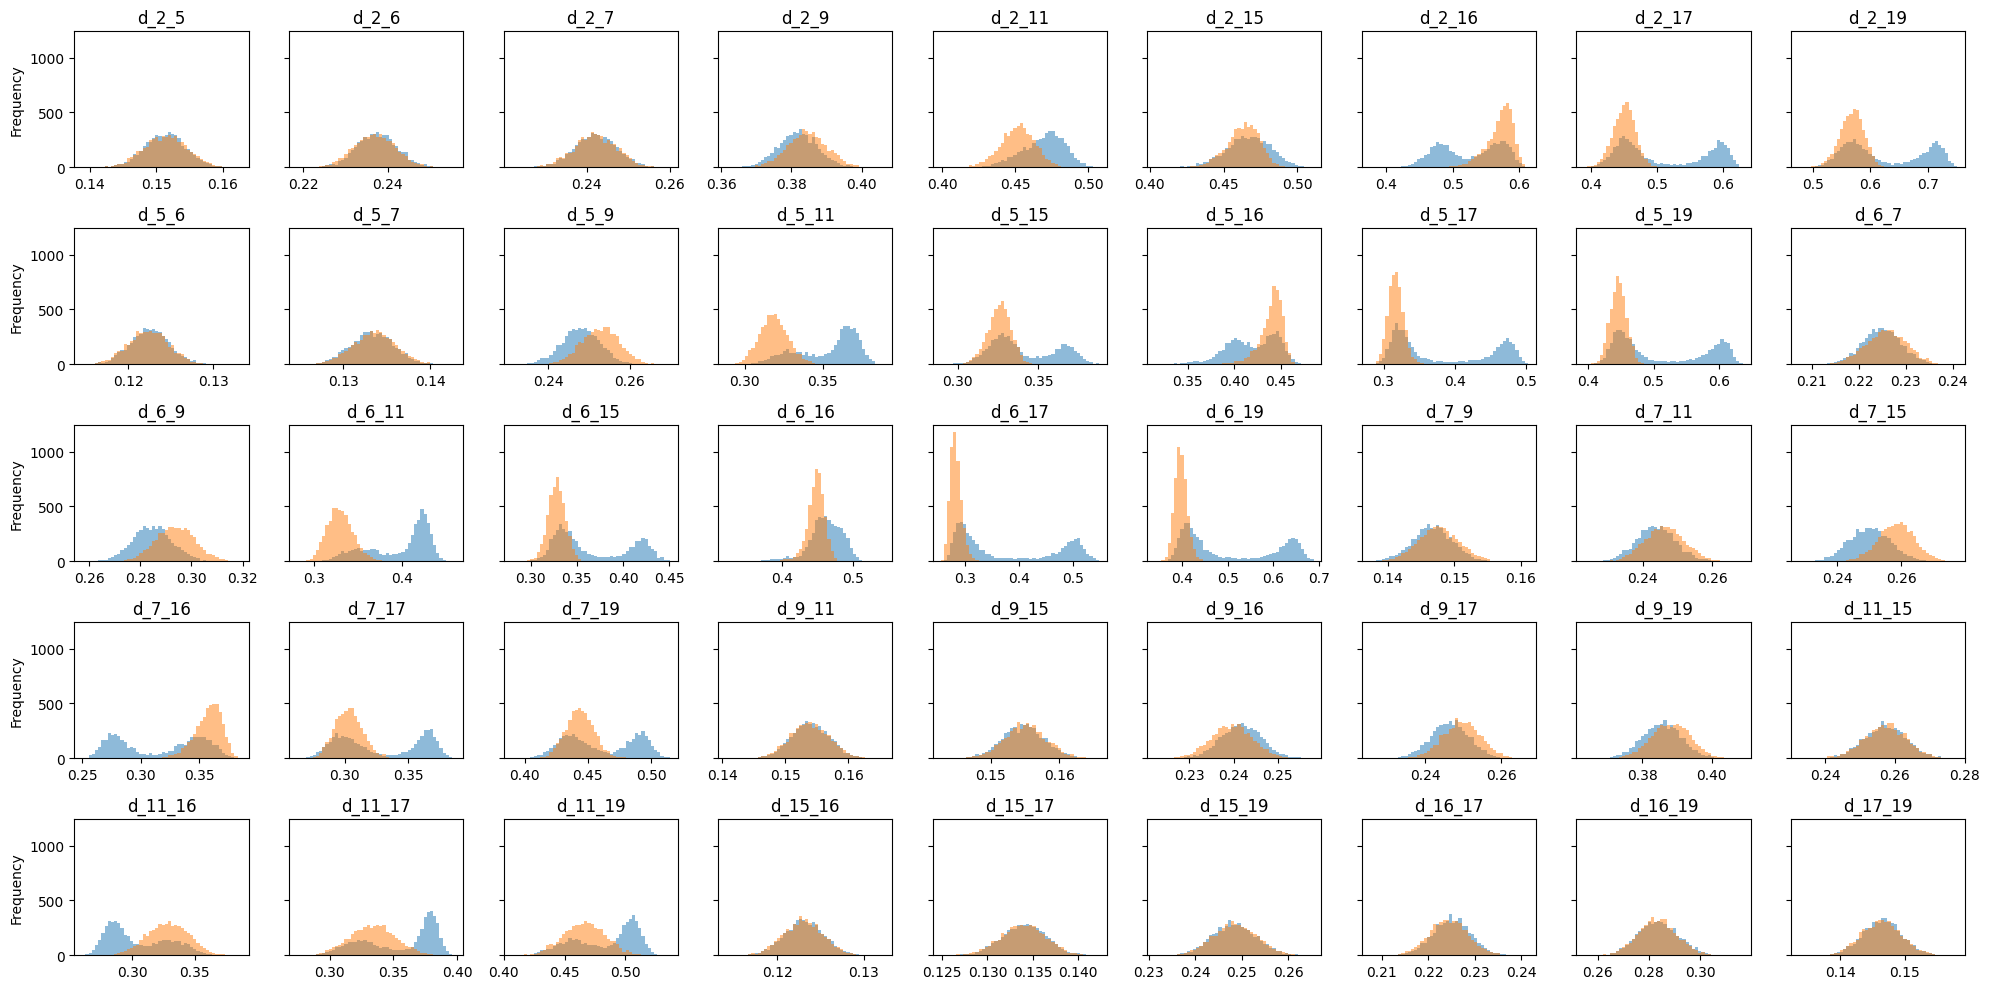

In [ ]:
descriptors_names = colvar.filter(regex='d_').columns.values

fig,axs = plt.subplots(5,9,figsize=(20,10),sharey=True)

for ax,desc in zip(axs.flatten(),descriptors_names):
    colvar.pivot(columns='labels')[desc].plot.hist(bins=50,alpha=0.5,ax=ax,legend=False)
    ax.set_title(desc)

plt.tight_layout()

### Train DeepLDA 

Define model

In [8]:
from mlcolvar.cvs import DeepLDA

#------------- PARAMETERS -------------
n_input           = dataset['data'].shape[-1]
nodes             = [n_input,30,30,5]
activation        = 'tanh'

lrate             = 0.001
sw_reg            = 0.05
l2_reg            = 1e-5

num_epochs        = 500
es_patience       = 20
es_min_delta      = 0.1

log_every         = 100
#--------------------------------------

nn_args = {'activation': activation}
options= {'nn': nn_args}

# MODEL
model = DeepLDA(nodes, n_states=n_states, options=options)

# OPTIMIZER: here we use adam
model.optimizer_name = "Adam"
model.optimizer_kwargs = {"lr": lrate, "weight_decay": l2_reg}

# REGULARIZATION: add regularization to the calculation of the S_w matrix
model.sw_reg = sw_reg

model

DeepLDA(
  (loss_fn): ReduceEigenvaluesLoss()
  (norm_in): Normalization(in_features=45, out_features=45, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=45, out_features=30, bias=True)
      (1): Tanh()
      (2): Linear(in_features=30, out_features=30, bias=True)
      (3): Tanh()
      (4): Linear(in_features=30, out_features=5, bias=True)
    )
  )
  (lda): LDA(in_features=5, out_features=1)
)

Define trainer and fit

In [9]:
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from mlcolvar.utils.trainer import MetricsCallback

# define callbacks
metrics = MetricsCallback()
early_stopping = EarlyStopping(monitor="valid_loss", 
    min_delta=es_min_delta, 
    patience=es_patience,
    mode="min")

# define trainer
trainer = lightning.Trainer(callbacks=[metrics, early_stopping],
                     max_epochs=num_epochs, logger=None, enable_checkpointing=False,
                     accelerator=accelerator)

# fit
trainer.fit( model, datamodule )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-07-03 12:18:57.880167: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-03 12:18:57.925091: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-03 12:18:58.932327: I tensorflow/core/util/port.cc:153] oneDNN cust

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃ In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ loss_fn │ ReduceEigenvaluesLoss │      0 │ train │     0 │        ? │         ? │
│ 1 │ norm_in │ Normalization         │      0 │ train │     0 │  [1, 45] │   [1, 45] │
│ 2 │ nn      │ FeedForward           │  2.5 K │ train │ 4.8 K │  [1, 45] │    [1, 5] │
│ 3 │ lda     │ LDA                   │      0 │ train │    10 │   [1, 5] │    [1, 1] │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┴──────────┴───────────┘

Trainable params: 2.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.5 K                                                                                                
Total estimated model params size (MB): 0.010                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 4.8 K

Output()

/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches 
(1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if 
you want to see logs for the training epoch.

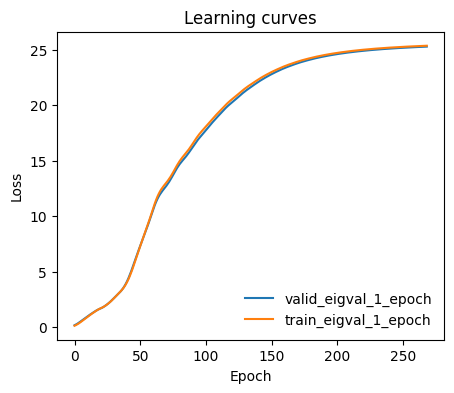

In [10]:
from mlcolvar.utils.plot import plot_metrics

ax = plot_metrics(metrics.metrics, 
                  keys=[x for x in  metrics.metrics.keys() if 'eigval' in x and 'epoch' in x],#['train_loss_epoch','valid_loss'],
                  yscale='linear')

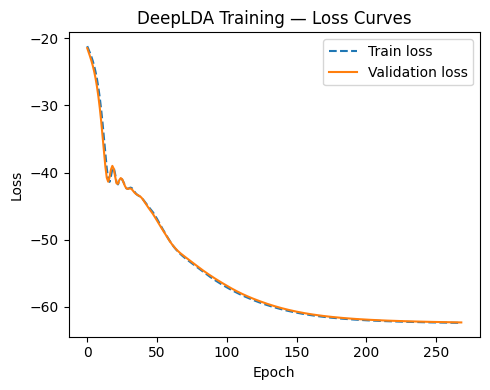

In [11]:
from mlcolvar.utils.plot import plot_metrics

ax = plot_metrics(metrics.metrics, 
                  keys=['train_loss_epoch','valid_loss'],
                  linestyles=['--','-'],
                  yscale='linear')

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("DeepLDA Training — Loss Curves")
ax.legend(["Train loss", "Validation loss"])

plt.tight_layout()

To better understand what the network is doing, we can inspect the output of the NN, before the application of LDA. 

--> **Question**: What are the differences with the input descriptors?

In [34]:
colvar.head()

,time,phi,psi,theta,xi,ene,d_2_5,d_2_6,d_2_7,d_2_9,...,d_11_17,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19,walker,labels
0,0.0,-2.36867,2.64432,-0.202258,0.048056,-41.45830,0.152064,0.233505,0.241173,0.379827,...,0.315937,0.452694,0.126976,0.130073,0.244001,0.227324,0.281913,0.148169,0,0
1,0.2,-2.01898,2.09469,0.183210,-0.178198,-26.62960,0.155184,0.240710,0.248149,0.389691,...,0.349922,0.475079,0.123270,0.131440,0.242846,0.224891,0.277797,0.147679,0,0
2,0.4,-1.13139,2.51985,-0.281653,0.294615,-2.19272,0.153063,0.234471,0.243033,0.374476,...,0.334340,0.473166,0.118082,0.137847,0.252739,0.232262,0.299266,0.149680,0,0
3,0.6,-1.64721,2.11313,0.231535,-0.183854,-15.40190,0.159816,0.246010,0.253918,0.392052,...,0.357145,0.482697,0.119017,0.136939,0.255320,0.226816,0.292098,0.151716,0,0
4,0.8,-1.69175,2.11844,-0.329683,0.034489,-10.46910,0.149141,0.235045,0.235168,0.376046,...,0.351763,0.474980,0.125090,0.132778,0.237818,0.225959,0.269223,0.143853,0,0


In [35]:
X_dist = colvar.filter(like='d_', axis=1)

X = torch.tensor(X_dist.values, dtype=torch.float32)
y = torch.tensor(colvar['labels'].values, dtype=torch.long)

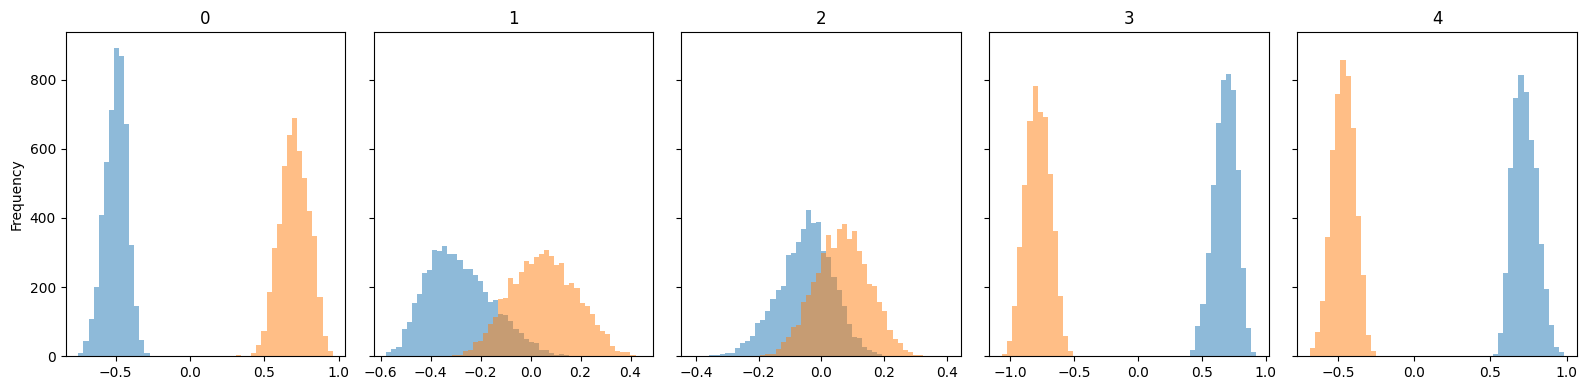

In [36]:
model.eval()
with torch.no_grad():
    hidden = model.forward_nn(X).numpy()
df_h = pd.DataFrame( hidden )
df_h ['label'] = y

# Plot histogram in the two state
fig,axs = plt.subplots(1,nodes[-1],figsize=(16,4),sharey=True)

hidden_names = [i for i in range(nodes[-1])]

for ax,desc in zip(axs.flatten(),hidden_names):
    df_h.pivot(columns='label')[desc].plot.hist(bins=50,alpha=0.5,ax=ax,legend=False)
    ax.set_title(desc)

plt.tight_layout()

Finally, we can look at the histogram of the CV (right), which shows that the two states are mapped around -1 and +1. To appreciate the discriminative power, we can also inspect the Ramachandran plot (left) of the two torsion angles phi and psi where we colored the points according to the value of the Deep-LDA CV.

In [48]:
# Define a few plotting functions

def plot_ramachandran(x,y,z,scatter=None, ax=None):
    # Setup plot
    if ax is None:
        _, ax = plt.subplots(figsize=(5,4.), dpi=100)
        ax.set_title(f'Ramachandran plot')

    # Plot countour plot
    h = ax.hexbin(x,y,C=z,cmap='fessa')
    cbar = plt.colorbar(h,ax=ax)
    cbar.set_label(f'Deep-LDA CV')

    ax.set_xlabel(r'$\phi$ [rad]')
    ax.set_ylabel(r'$\psi$ [rad]')

def plot_cv_histogram(s,label=None,ax=None,**kwargs):
    # Setup plot
    if ax is None:
        _, ax = plt.subplots(figsize=(5,4.), dpi=100)
        ax.set_title('Histogram')

    if (type(s)==torch.Tensor):
        s = s.squeeze(1).detach().numpy()

    # Plot histogram
    ax.hist(s,**kwargs)
    if label is not None:
        ax.set_xlabel(label)

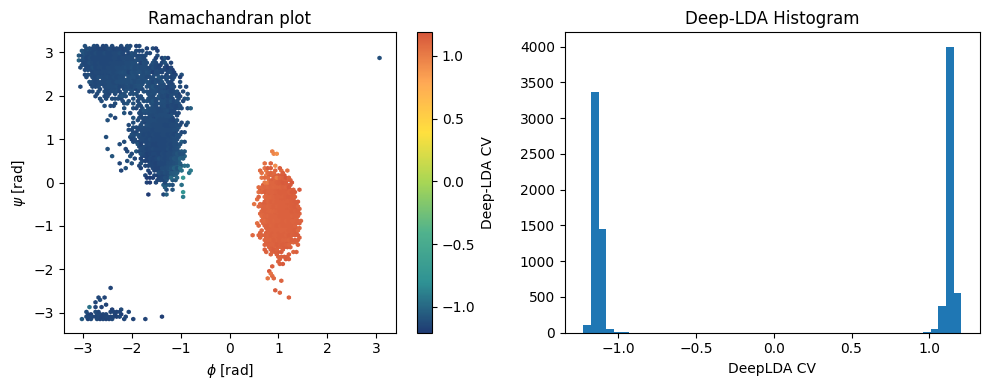

In [49]:
_, axs = plt.subplots(1,2, figsize=(10,4.), dpi=100)

axs[0].set_title('Ramachandran plot')
with torch.no_grad():
    s = model(X)
    
plot_ramachandran(colvar['phi'],colvar['psi'],s,ax=axs[0])

# Calculate CV values over training set
axs[1].set_title(f'Deep-LDA Histogram')
plot_cv_histogram(s, label="DeepLDA CV", bins=50, ax=axs[1])

plt.tight_layout()